# Comparative study of preprocessing strategies for fall detection before FL

Este notebook serve para estudar varias estrategias de pre-processamento antes de aplicares Federated Learning.

Ideia central:
- comparar variantes de pre-processamento no mesmo formato comum
- perceber como mudam as distribuicoes por dataset e por cliente

As variantes testadas sao:
- `baseline_zscore`
- `robust_clip`
- `magnitude_features`
- `smoothed_magnitude`
- `magnitude_only`


In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from fl_preprocessing_experiments import VARIANTS, run_experiments, run_experiments_detailed

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

variant_table = pd.DataFrame([
    {
        'variant': v.name,
        'description': v.description,
        'smooth_window': v.smooth_window,
        'add_magnitude': v.add_magnitude,
        'magnitude_only': v.magnitude_only,
        'scaling': v.scaling,
        'clip_quantile': v.clip_quantile,
    }
    for v in VARIANTS
])
variant_table

,variant,description,smooth_window,add_magnitude,magnitude_only,scaling,clip_quantile
0,baseline_zscore,Resample para 20 Hz e normalizacao z-score por...,NaN,False,False,zscore,NaN
1,robust_clip,"Resample, clipping por quantis e escala robust...",NaN,False,False,robust,0.01
2,magnitude_features,"Mantem eixos, adiciona magnitudes e aplica z-s...",NaN,True,False,zscore,NaN
3,smoothed_magnitude,"Suavizacao media movel, clipping, magnitudes e...",5.0,True,False,robust,0.01
4,magnitude_only,Reduz para acc_mag e gyro_mag para minimizar d...,NaN,True,True,robust,0.01


## 1. Correr as experiencias

Podes alterar `max_trials_per_client`.
- `5` e um estudo rapido
- `None` corre tudo, mas demora mais


In [95]:
summary, client_summary, preview = run_experiments(
    output_dir='preprocessing_outputs',
    max_trials_per_client=5,
    preview_windows_per_variant=2,
)

windows_df, trials_df, sisfall_client_coverage = run_experiments_detailed(
    max_trials_per_client=5,
)

summary.sort_values(['variant', 'dataset']).reset_index(drop=True)

,dataset,windows,clients,positive_windows,variant,positive_ratio,window_seconds,target_hz,description
0,KFall,976,32,196,baseline_zscore,0.200820,3.0,20,Resample para 20 Hz e normalizacao z-score por...
1,SisFall,9085,38,432,baseline_zscore,0.047551,3.0,20,Resample para 20 Hz e normalizacao z-score por...
2,UpFall,2141,17,170,baseline_zscore,0.079402,3.0,20,Resample para 20 Hz e normalizacao z-score por...
3,KFall,976,32,196,magnitude_features,0.200820,3.0,20,"Mantem eixos, adiciona magnitudes e aplica z-s..."
4,SisFall,9085,38,432,magnitude_features,0.047551,3.0,20,"Mantem eixos, adiciona magnitudes e aplica z-s..."
5,UpFall,2141,17,170,magnitude_features,0.079402,3.0,20,"Mantem eixos, adiciona magnitudes e aplica z-s..."
6,KFall,976,32,196,magnitude_only,0.200820,3.0,20,Reduz para acc_mag e gyro_mag para minimizar d...
7,SisFall,9085,38,432,magnitude_only,0.047551,3.0,20,Reduz para acc_mag e gyro_mag para minimizar d...
8,UpFall,2141,17,170,magnitude_only,0.079402,3.0,20,Reduz para acc_mag e gyro_mag para minimizar d...
9,KFall,976,32,196,robust_clip,0.200820,3.0,20,"Resample, clipping por quantis e escala robust..."


## 2. Tabelas base

O `summary` ajuda a ver cobertura por dataset. O `client_summary` mostra o equilibrio por cliente. O `windows_df` e o mais importante para estudar o efeito real das variantes.

In [96]:
summary.sort_values(['dataset', 'variant'])

,dataset,windows,clients,positive_windows,variant,positive_ratio,window_seconds,target_hz,description
0,KFall,976,32,196,baseline_zscore,0.200820,3.0,20,Resample para 20 Hz e normalizacao z-score por...
6,KFall,976,32,196,magnitude_features,0.200820,3.0,20,"Mantem eixos, adiciona magnitudes e aplica z-s..."
12,KFall,976,32,196,magnitude_only,0.200820,3.0,20,Reduz para acc_mag e gyro_mag para minimizar d...
3,KFall,976,32,196,robust_clip,0.200820,3.0,20,"Resample, clipping por quantis e escala robust..."
9,KFall,976,32,196,smoothed_magnitude,0.200820,3.0,20,"Suavizacao media movel, clipping, magnitudes e..."
1,SisFall,9085,38,432,baseline_zscore,0.047551,3.0,20,Resample para 20 Hz e normalizacao z-score por...
7,SisFall,9085,38,432,magnitude_features,0.047551,3.0,20,"Mantem eixos, adiciona magnitudes e aplica z-s..."
13,SisFall,9085,38,432,magnitude_only,0.047551,3.0,20,Reduz para acc_mag e gyro_mag para minimizar d...
4,SisFall,9085,38,432,robust_clip,0.047551,3.0,20,"Resample, clipping por quantis e escala robust..."
10,SisFall,9085,38,432,smoothed_magnitude,0.047551,3.0,20,"Suavizacao media movel, clipping, magnitudes e..."


In [97]:
client_summary.sort_values(['dataset', 'variant', 'client']).head(30)

,dataset,client,windows,positive_windows,variant,positive_ratio
0,KFall,SA06,30,4,baseline_zscore,0.133333
1,KFall,SA07,31,5,baseline_zscore,0.161290
2,KFall,SA08,30,5,baseline_zscore,0.166667
3,KFall,SA09,32,6,baseline_zscore,0.187500
4,KFall,SA10,30,4,baseline_zscore,0.133333
5,KFall,SA11,31,4,baseline_zscore,0.129032
6,KFall,SA12,28,6,baseline_zscore,0.214286
7,KFall,SA13,30,6,baseline_zscore,0.200000
8,KFall,SA14,32,6,baseline_zscore,0.187500
9,KFall,SA15,29,4,baseline_zscore,0.137931


## 3. Graficos comparativos das variantes

Nota importante: o numero de janelas tende a ser igual entre variantes porque o janelamento e o mesmo. O que realmente muda sao as features extraidas e as distribuicoes dessas features.

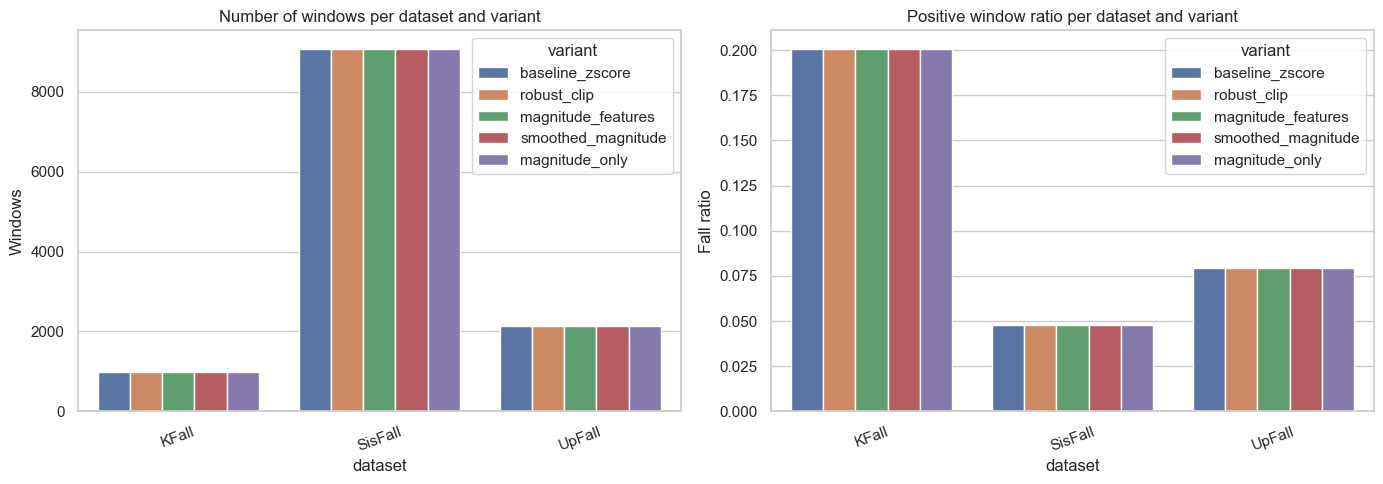

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='dataset', y='windows', hue='variant', ax=axes[0])
axes[0].set_title('Number of windows per dataset and variant')
axes[0].set_ylabel('Windows')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=summary, x='dataset', y='positive_ratio', hue='variant', ax=axes[1])
axes[1].set_title('Positive window ratio per dataset and variant')
axes[1].set_ylabel('Fall ratio')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

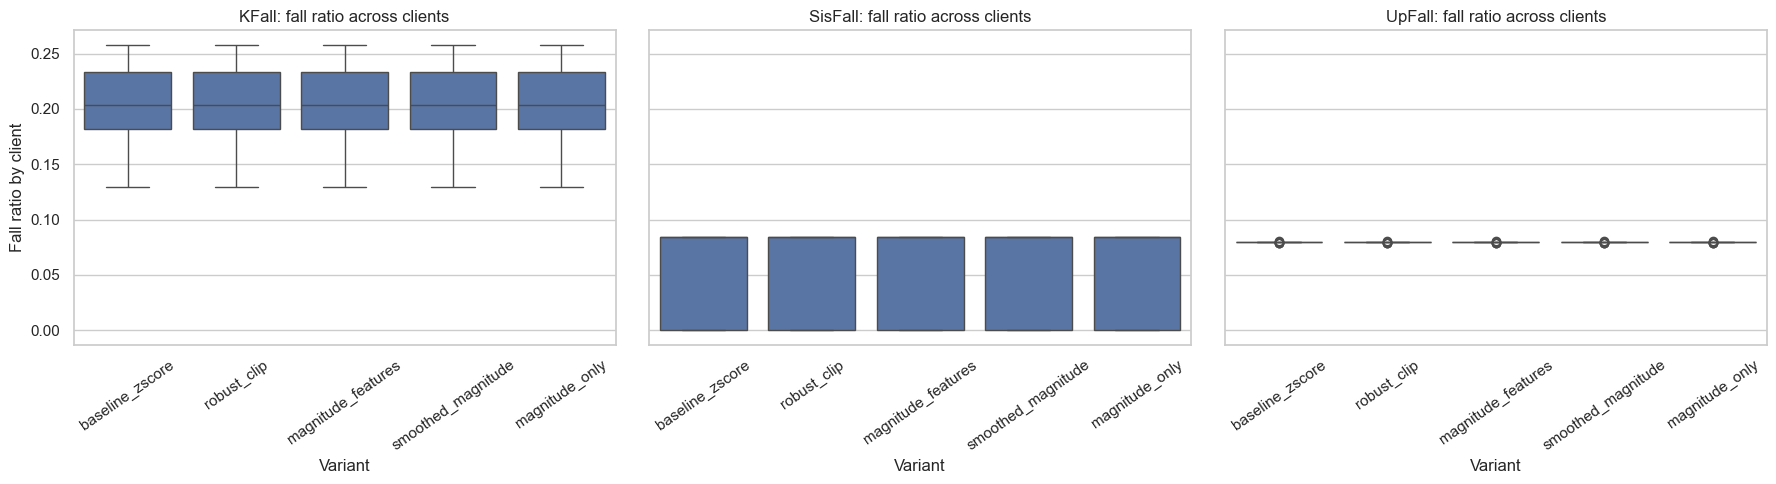

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, dataset_name in zip(axes, sorted(client_summary['dataset'].unique())):
    subset = client_summary[client_summary['dataset'] == dataset_name]
    sns.boxplot(data=subset, x='variant', y='positive_ratio', ax=ax)
    ax.set_title(f'{dataset_name}: fall ratio across clients')
    ax.tick_params(axis='x', rotation=35)
    ax.set_xlabel('Variant')
    ax.set_ylabel('Fall ratio by client')
plt.tight_layout()

## 4. Como mudam as features entre variantes

Aqui olhamos para features-resumo por janela. Isto ja permite ver se uma variante ajuda a separar `Fall` de `ADL`.

In [100]:
available_feature_columns = [
    c for c in windows_df.columns
    if c.endswith('_energy') or c.endswith('_std') or c.endswith('_maxabs')
]

candidate_features = [
    'acc_mag_energy',
    'gyro_mag_energy',
    'acc_x_std',
    'gyro_x_std',
]
selected_features = [c for c in candidate_features if c in available_feature_columns]
selected_features

['acc_mag_energy', 'gyro_mag_energy', 'acc_x_std', 'gyro_x_std']

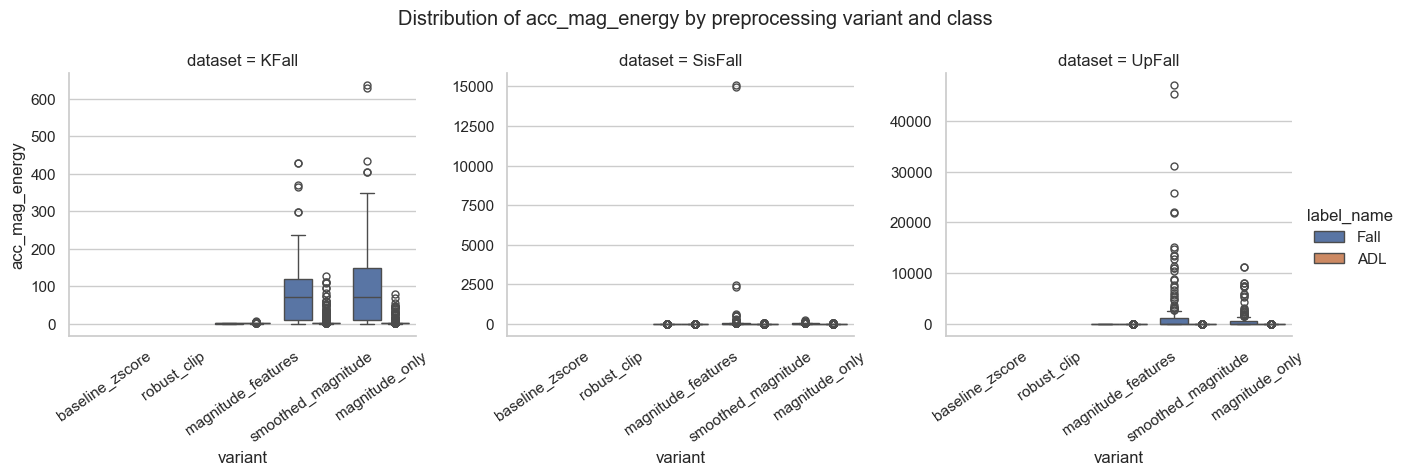

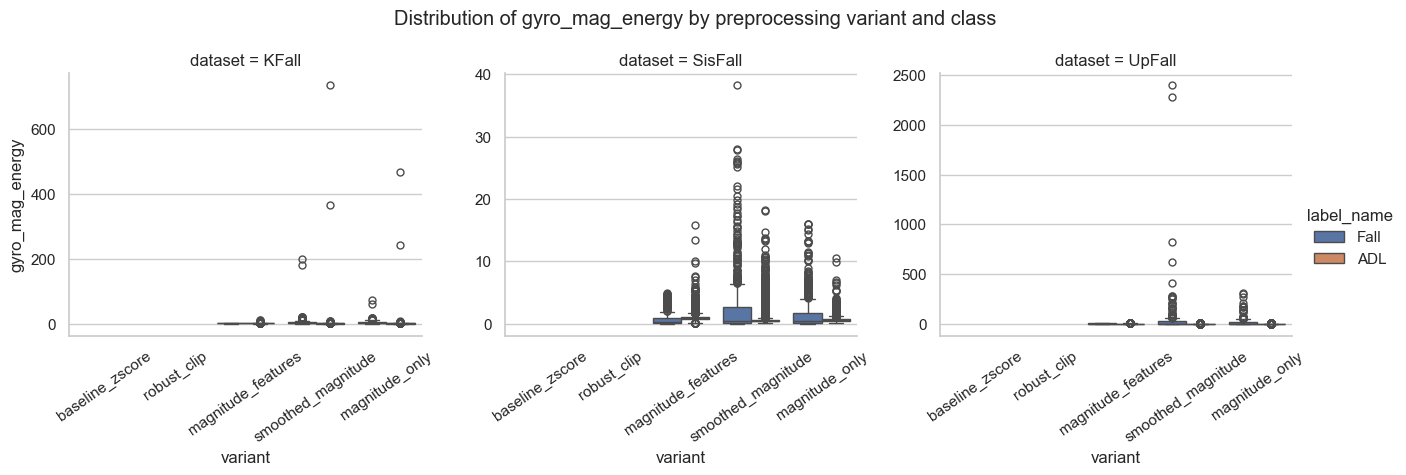

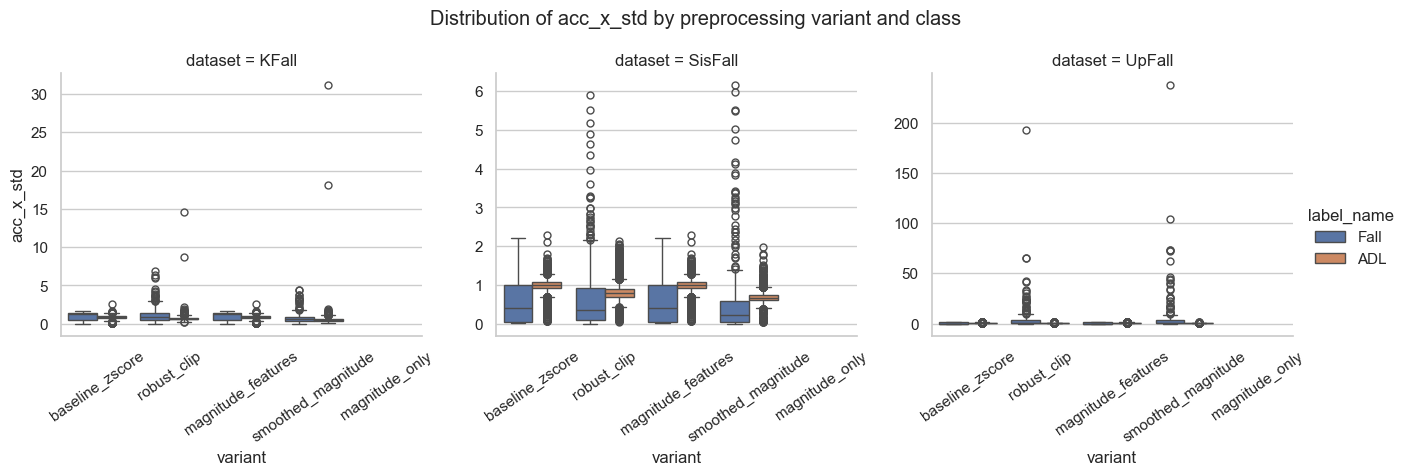

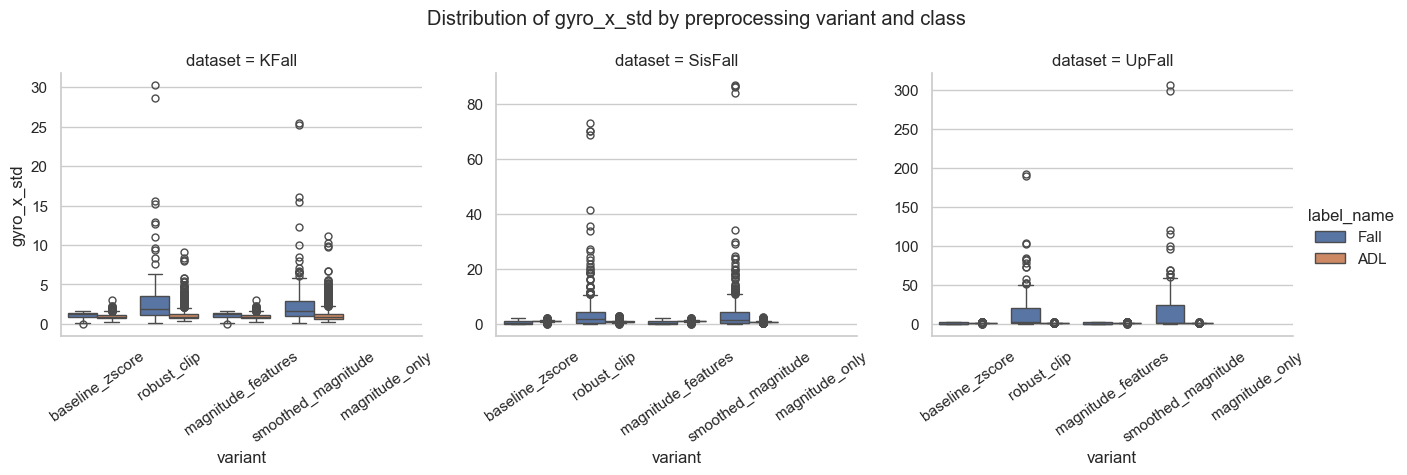

In [101]:
plot_df = windows_df.copy()
plot_df['label_name'] = plot_df['label'].map({0: 'ADL', 1: 'Fall'})

for feature in selected_features:
    g = sns.catplot(
        data=plot_df,
        kind='box',
        x='variant',
        y=feature,
        hue='label_name',
        col='dataset',
        sharey=False,
        height=4,
        aspect=1.1,
    )
    g.fig.subplots_adjust(top=0.82)
    g.fig.suptitle(f'Distribution of {feature} by preprocessing variant and class')
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=35)
    plt.show()

In [102]:
separation_rows = []
for variant, variant_df in windows_df.groupby('variant'):
    for dataset_name, dataset_df in variant_df.groupby('dataset'):
        for feature in selected_features:
            fall_values = dataset_df.loc[dataset_df['label'] == 1, feature].dropna()
            adl_values = dataset_df.loc[dataset_df['label'] == 0, feature].dropna()
            if len(fall_values) == 0 or len(adl_values) == 0:
                continue
            pooled_std = np.sqrt((fall_values.var(ddof=0) + adl_values.var(ddof=0)) / 2)
            effect_size = 0.0 if pooled_std == 0 else (fall_values.mean() - adl_values.mean()) / pooled_std
            separation_rows.append({
                'variant': variant,
                'dataset': dataset_name,
                'feature': feature,
                'fall_mean': fall_values.mean(),
                'adl_mean': adl_values.mean(),
                'cohens_d': effect_size,
            })

separation_df = pd.DataFrame(separation_rows)
separation_df.sort_values(['feature', 'dataset', 'cohens_d'], ascending=[True, True, False]).head(30)

,variant,dataset,feature,fall_mean,adl_mean,cohens_d
30,smoothed_magnitude,KFall,acc_mag_energy,83.312377,4.016087,1.368342
18,magnitude_only,KFall,acc_mag_energy,99.948629,2.455097,1.277651
6,magnitude_features,KFall,acc_mag_energy,1.484524,1.032754,0.537732
20,magnitude_only,SisFall,acc_mag_energy,11.355297,0.683604,0.650028
34,smoothed_magnitude,SisFall,acc_mag_energy,101.999552,0.379214,0.139163
10,magnitude_features,SisFall,acc_mag_energy,1.103028,1.005930,0.083757
22,magnitude_only,UpFall,acc_mag_energy,857.544444,0.603438,0.598334
38,smoothed_magnitude,UpFall,acc_mag_energy,2494.247716,0.432656,0.520006
14,magnitude_features,UpFall,acc_mag_energy,1.256797,1.000730,0.231184
24,robust_clip,KFall,acc_x_std,1.176564,0.736313,0.471003


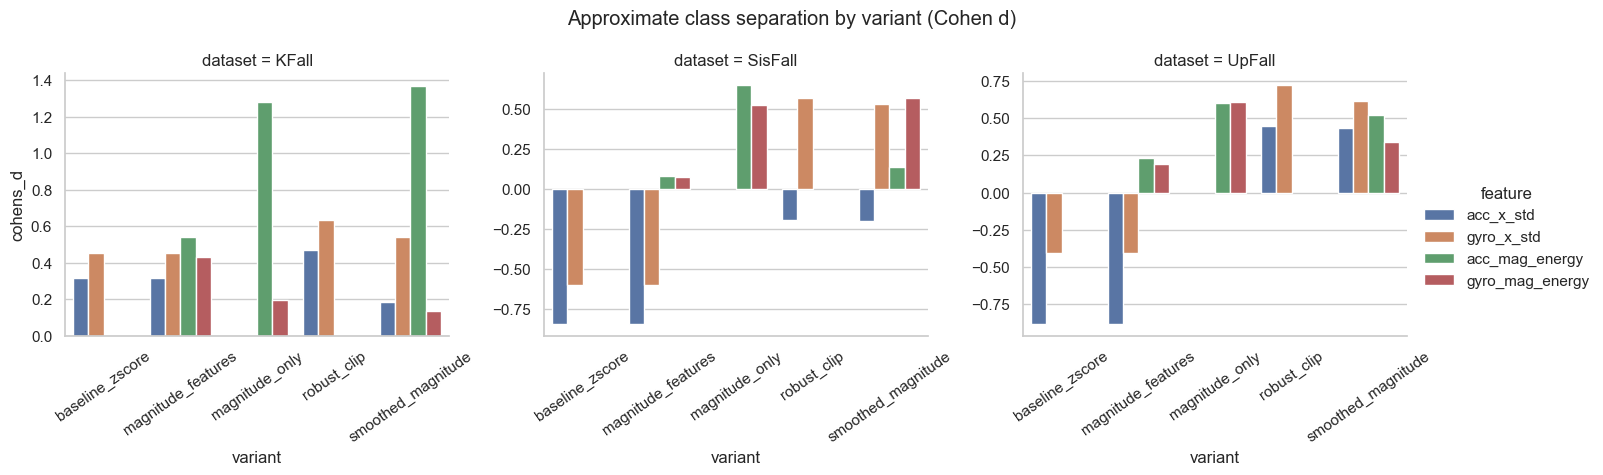

In [103]:
if not separation_df.empty:
    g = sns.catplot(
        data=separation_df,
        kind='bar',
        x='variant',
        y='cohens_d',
        hue='feature',
        col='dataset',
        sharey=False,
        height=4,
        aspect=1.2,
    )
    g.fig.subplots_adjust(top=0.82)
    g.fig.suptitle('Approximate class separation by variant (Cohen d)')
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=35)
    plt.show()

## 5. Foco no SisFall: clientes sem quedas

Esta parte responde diretamente a tua pergunta.

No `SisFall`, varios clientes so tem `ADL` e nao tem qualquer janela positiva. Isto cria uma decisao metodologica:
- manter todos os clientes: mais realista para FL heterogeneo e para cenarios de deployment
- filtrar clientes sem quedas: melhor para estudar deteccao supervisionada pura, mas menos realista

Abaixo medimos isso.

In [104]:
sisfall_client_coverage.sort_values(['has_fall_data', 'fall_trials', 'client'])

,client,n_trials,fall_trials,has_fall_data,fall_ratio_trials
23,SE01,5,0,False,0.0
24,SE02,5,0,False,0.0
25,SE03,5,0,False,0.0
26,SE04,5,0,False,0.0
27,SE05,5,0,False,0.0
29,SE07,5,0,False,0.0
30,SE08,5,0,False,0.0
31,SE09,5,0,False,0.0
32,SE10,5,0,False,0.0
33,SE11,5,0,False,0.0


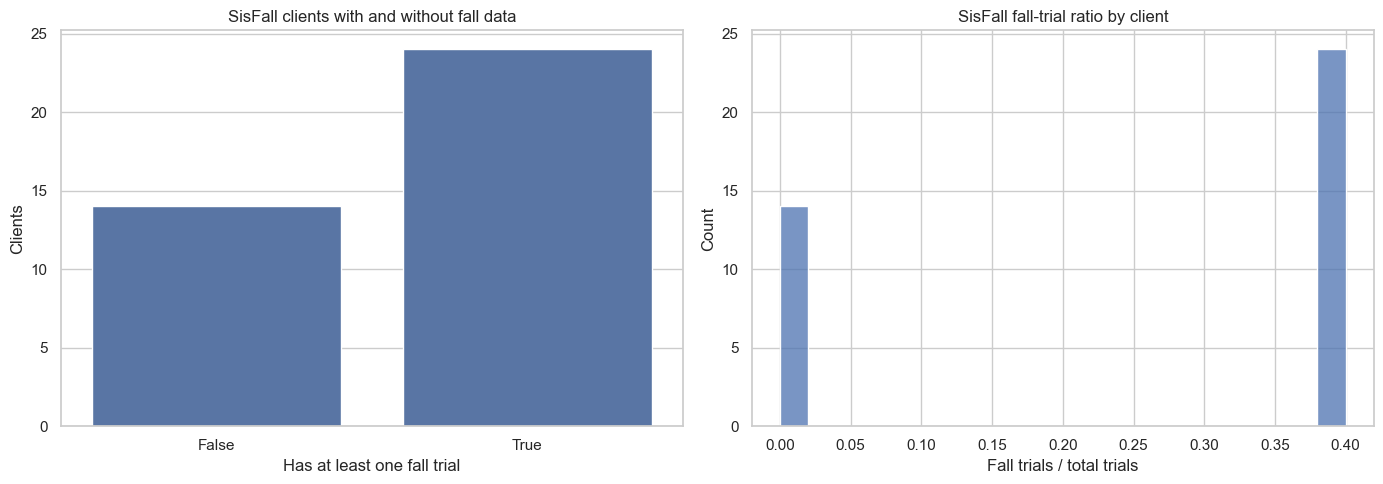

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=sisfall_client_coverage, x='has_fall_data', ax=axes[0])
axes[0].set_title('SisFall clients with and without fall data')
axes[0].set_xlabel('Has at least one fall trial')
axes[0].set_ylabel('Clients')

sns.histplot(data=sisfall_client_coverage, x='fall_ratio_trials', bins=20, ax=axes[1])
axes[1].set_title('SisFall fall-trial ratio by client')
axes[1].set_xlabel('Fall trials / total trials')

plt.tight_layout()

In [106]:
sisfall_windows = windows_df[windows_df['dataset'] == 'SisFall'].copy()
clients_with_fall = set(sisfall_client_coverage.loc[sisfall_client_coverage['has_fall_data'], 'client'])

sisfall_compare = pd.concat([
    sisfall_windows.assign(selection='All clients'),
    sisfall_windows[sisfall_windows['client'].isin(clients_with_fall)].assign(selection='Only clients with falls'),
], ignore_index=True)

sisfall_selection_summary = (
    sisfall_compare.groupby(['selection', 'variant'])
    .agg(
        windows=('trial_id', 'size'),
        clients=('client', 'nunique'),
        positive_windows=('label', 'sum'),
    )
    .reset_index()
)
sisfall_selection_summary['positive_ratio'] = (
    sisfall_selection_summary['positive_windows'] / sisfall_selection_summary['windows']
)
sisfall_selection_summary

,selection,variant,windows,clients,positive_windows,positive_ratio
0,All clients,baseline_zscore,9085,38,432,0.047551
1,All clients,magnitude_features,9085,38,432,0.047551
2,All clients,magnitude_only,9085,38,432,0.047551
3,All clients,robust_clip,9085,38,432,0.047551
4,All clients,smoothed_magnitude,9085,38,432,0.047551
5,Only clients with falls,baseline_zscore,5112,24,432,0.084507
6,Only clients with falls,magnitude_features,5112,24,432,0.084507
7,Only clients with falls,magnitude_only,5112,24,432,0.084507
8,Only clients with falls,robust_clip,5112,24,432,0.084507
9,Only clients with falls,smoothed_magnitude,5112,24,432,0.084507


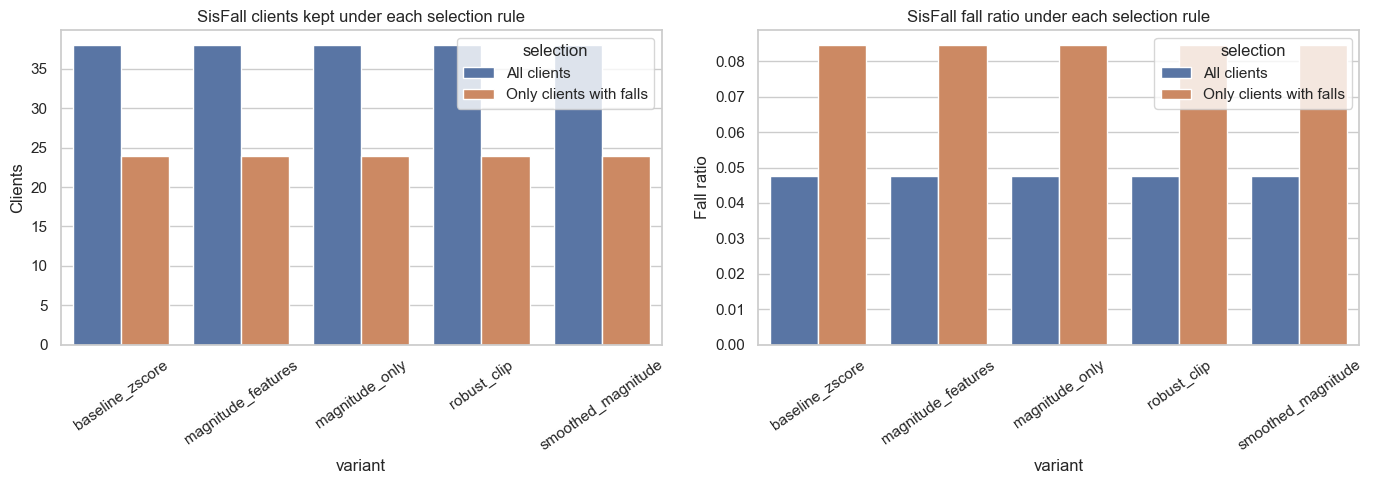

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=sisfall_selection_summary, x='variant', y='clients', hue='selection', ax=axes[0])
axes[0].set_title('SisFall clients kept under each selection rule')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylabel('Clients')

sns.barplot(data=sisfall_selection_summary, x='variant', y='positive_ratio', hue='selection', ax=axes[1])
axes[1].set_title('SisFall fall ratio under each selection rule')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylabel('Fall ratio')

plt.tight_layout()

## 6. Recomendacao metodologica para o SisFall

Recomendacao pratica:
- para estudar o pre-processamento de forma fiel ao FL, **mantem todos os clientes**
- para uma analise secundaria de classificacao supervisionada mais limpa, cria em paralelo uma versao filtrada com **apenas clientes que tenham quedas**

Porque manter todos os clientes faz sentido:
- em FL, a heterogeneidade entre clientes e parte do problema real
- clientes sem quedas representam cenarios reais onde so existem atividades normais
- excluir esses clientes pode inflacionar artificialmente a taxa de positivos e simplificar demasiado o problema

Porque a versao filtrada tambem pode ser util:
- ajuda a perceber se uma variante de pre-processamento melhora a separacao `Fall` vs `ADL` sem o efeito de clientes totalmente negativos
- e uma boa analise de sensibilidade

Conclusao recomendada para a tese:
- usa **todos os clientes** como configuracao principal
- reporta tambem um **estudo complementar** com filtro de clientes com quedas no `SisFall`


## 7. Interpretacao dos resultados e tabela-resumo

Nesta fase, a leitura principal dos resultados e:
- as variantes nao mudam o numero de janelas, mas mudam bastante a representacao numerica das janelas
- `magnitude_features` e `magnitude_only` sao especialmente relevantes quando ha heterogeneidade de orientacao e posicionamento do sensor entre clientes
- `robust_clip` e `smoothed_magnitude` sao promissoras quando existem outliers, ruido e amplitude muito desigual entre clientes
- no `SisFall`, manter clientes sem quedas torna o problema mais realista para FL, mas tambem mais desequilibrado
- para redes neuronais e importante garantir que a escala, o comprimento das sequencias e a representacao dos sinais sejam consistentes entre clientes


In [108]:
feature_priority = [
    'acc_mag_energy',
    'gyro_mag_energy',
    'acc_x_std',
    'gyro_x_std',
]

summary_rows = []
for variant in VARIANTS:
    variant_name = variant.name
    variant_sep = separation_df[separation_df['variant'] == variant_name].copy() if 'separation_df' in globals() else pd.DataFrame()

    top_feature = None
    top_effect = np.nan
    if not variant_sep.empty:
        variant_sep['abs_d'] = variant_sep['cohens_d'].abs()
        preferred = variant_sep[variant_sep['feature'].isin(feature_priority)]
        use_df = preferred if not preferred.empty else variant_sep
        top_row = use_df.sort_values('abs_d', ascending=False).iloc[0]
        top_feature = top_row['feature']
        top_effect = top_row['cohens_d']

    if variant_name == 'baseline_zscore':
        interpretation = 'Baseline simples. Boa referencia inicial, mas menos robusta a outliers e a heterogeneidade entre clientes.'
        recommended_for = 'Baseline para ML classico e comparacao inicial com NN.'
    elif variant_name == 'robust_clip':
        interpretation = 'Mais estavel quando ha amplitudes extremas ou clientes com sensores ruidosos. Boa candidata para FL heterogeneo.'
        recommended_for = 'FL com forte heterogeneidade e modelos sensiveis a escala.'
    elif variant_name == 'magnitude_features':
        interpretation = 'Mantem informacao dos eixos e acrescenta invariancia parcial a orientacao. Costuma ser uma escolha equilibrada.'
        recommended_for = 'Cenarios mistos: modelos classicos, CNNs e comparacao entre datasets.'
    elif variant_name == 'smoothed_magnitude':
        interpretation = 'Reduz ruido local e preserva informacao energetica. Pode ajudar redes neuronais quando os sinais sao irregulares.'
        recommended_for = 'CNN/LSTM/Transformers com sinais ruidosos.'
    elif variant_name == 'magnitude_only':
        interpretation = 'Maximiza robustez a orientacao, mas perde detalhe direcional. Boa para forte desvio entre clientes, menos rica para certos modelos.'
        recommended_for = 'FL com grande variacao de orientacao/posicionamento do sensor.'
    elif variant_name == 'client_zscore':
        interpretation = 'Normaliza por cliente local, o que aproxima melhor o ambiente real de FL e reduz leakage entre clientes.'
        recommended_for = 'Treino federado com modelos classicos e redes neuronais.'
    elif variant_name == 'client_raw_plus_magnitude':
        interpretation = 'Combina detalhe direcional com invariancia parcial a orientacao, usando estatisticas locais por cliente.'
        recommended_for = 'Boa candidata principal para FL heterogeneo.'
    elif variant_name == 'gravity_removed_magnitude':
        interpretation = 'Reduz o efeito da postura e da inclinacao do sensor, focando mais a dinamica do movimento.'
        recommended_for = 'Clientes com orientacao/colocacao muito diferentes entre si.'
    elif variant_name == 'sequence_ready_nn':
        interpretation = 'Pipeline pensado para redes neuronais: sinais mais estaveis, escalados localmente e com estrutura temporal consistente.'
        recommended_for = 'CNN, LSTM, GRU e Transformers locais no FL.'
    elif variant_name == 'frequency_augmented':
        interpretation = 'Acrescenta informacao espectral por janela, o que pode ajudar a distinguir movimentos bruscos de ADLs intensas.'
        recommended_for = 'Modelos classicos fortes e comparacao com redes neuronais.'
    elif variant_name == 'quality_filtered_magnitude':
        interpretation = 'Remove janelas com variabilidade demasiado baixa e tende a reduzir ruido ou segmentos pouco informativos.'
        recommended_for = 'Clientes com janelas degradadas ou sinais pouco estaveis.'
    elif variant_name == 'client_balanced_magnitude':
        interpretation = 'Balanceia Fall e ADL dentro de cada cliente, o que pode reduzir enviesamento no treino local federado.'
        recommended_for = 'FL com forte desequilibrio local de classes.'
    else:
        interpretation = ''
        recommended_for = ''

    summary_rows.append({
        'strategy': variant_name,
        'description': variant.description,
        'best_observed_feature': top_feature,
        'best_cohens_d': top_effect,
        'analysis_of_preprocessed_data': interpretation,
        'recommended_use': recommended_for,
    })

strategy_summary_df = pd.DataFrame(summary_rows)
strategy_summary_df



,strategy,description,best_observed_feature,best_cohens_d,analysis_of_preprocessed_data,recommended_use
0,baseline_zscore,Resample para 20 Hz e normalizacao z-score por...,acc_x_std,-0.879926,"Baseline simples. Boa referencia inicial, mas ...",Baseline para ML classico e comparacao inicial...
1,robust_clip,"Resample, clipping por quantis e escala robust...",gyro_x_std,0.719407,Mais estavel quando ha amplitudes extremas ou ...,FL com forte heterogeneidade e modelos sensive...
2,magnitude_features,"Mantem eixos, adiciona magnitudes e aplica z-s...",acc_x_std,-0.879926,Mantem informacao dos eixos e acrescenta invar...,"Cenarios mistos: modelos classicos, CNNs e com..."
3,smoothed_magnitude,"Suavizacao media movel, clipping, magnitudes e...",acc_mag_energy,1.368342,Reduz ruido local e preserva informacao energe...,CNN/LSTM/Transformers com sinais ruidosos.
4,magnitude_only,Reduz para acc_mag e gyro_mag para minimizar d...,acc_mag_energy,1.277651,"Maximiza robustez a orientacao, mas perde deta...",FL com grande variacao de orientacao/posiciona...


Sabendo que vais usar treinos locais com modelos classicos e redes neuronais, estas sao as experiencias mais importantes a acrescentar.


In [109]:
next_tests_df = pd.DataFrame([
    {
        'test_to_add': 'Normalizacao por cliente local',
        'why_it_matters_for_FL': 'Mais fiel ao FL do que normalizar por trial; preserva o facto de cada cliente ter a sua propria distribuicao.',
        'priority': 'Muito alta',
    },
    {
        'test_to_add': 'Comparar janela 2s, 3s e 5s',
        'why_it_matters_for_FL': 'Afeta diretamente o sinal observado por CNN/LSTM e a rapidez de deteccao da queda.',
        'priority': 'Muito alta',
    },
    {
        'test_to_add': 'Comparar overlap 0%, 50% e 75%',
        'why_it_matters_for_FL': 'Muda o numero de amostras locais por cliente e o equilibrio entre redundancia e cobertura temporal.',
        'priority': 'Alta',
    },
    {
        'test_to_add': 'Raw axes vs magnitudes vs combinacao dos dois',
        'why_it_matters_for_FL': 'Ajuda a perceber se a invariancia a orientacao compensa a perda de detalhe direcional.',
        'priority': 'Muito alta',
    },
    {
        'test_to_add': 'Suavizacao e filtros passa-baixo',
        'why_it_matters_for_FL': 'Pode melhorar robustez a ruido, sobretudo em datasets e clientes mais instaveis.',
        'priority': 'Alta',
    },
    {
        'test_to_add': 'Padding/truncation consistente para sequencias',
        'why_it_matters_for_FL': 'Essencial para redes neuronais que esperam tensores com forma fixa.',
        'priority': 'Muito alta',
    },
    {
        'test_to_add': 'Balanceamento local por cliente',
        'why_it_matters_for_FL': 'Importante porque alguns clientes terao muito menos quedas; afeta bastante o treino local.',
        'priority': 'Alta',
    },
    {
        'test_to_add': 'Data augmentation temporal',
        'why_it_matters_for_FL': 'Pode ajudar redes neuronais quando o numero de quedas por cliente e reduzido.',
        'priority': 'Media/Alta',
    },
    {
        'test_to_add': 'Features no dominio do tempo vs frequencia',
        'why_it_matters_for_FL': 'Modelos classicos podem beneficiar de features agregadas; CNNs podem preferir sinal mais cru.',
        'priority': 'Media',
    },
])
next_tests_df


,test_to_add,why_it_matters_for_FL,priority
0,Normalizacao por cliente local,Mais fiel ao FL do que normalizar por trial; p...,Muito alta
1,"Comparar janela 2s, 3s e 5s",Afeta diretamente o sinal observado por CNN/LS...,Muito alta
2,"Comparar overlap 0%, 50% e 75%",Muda o numero de amostras locais por cliente e...,Alta
3,Raw axes vs magnitudes vs combinacao dos dois,Ajuda a perceber se a invariancia a orientacao...,Muito alta
4,Suavizacao e filtros passa-baixo,"Pode melhorar robustez a ruido, sobretudo em d...",Alta
5,Padding/truncation consistente para sequencias,Essencial para redes neuronais que esperam ten...,Muito alta
6,Balanceamento local por cliente,Importante porque alguns clientes terao muito ...,Alta
7,Data augmentation temporal,Pode ajudar redes neuronais quando o numero de...,Media/Alta
8,Features no dominio do tempo vs frequencia,Modelos classicos podem beneficiar de features...,Media


In [110]:
additional_preprocessing_strategies_df = pd.DataFrame([
    {
        'strategy': 'gravity_removal_highpass',
        'category': 'Signal cleaning',
        'objective': 'Separar melhor movimento dinamico da componente gravitacional.',
        'expected_FL_impact': 'Reduz diferencas de orientacao entre clientes.',
        'expected_NN_impact': 'Ajuda redes a focarem-se no movimento e nao na postura.',
        'priority': 'Alta',
    },
    {
        'strategy': 'missing_value_handling',
        'category': 'Data quality',
        'objective': 'Tratar gaps, amostras corrompidas e timestamps irregulares.',
        'expected_FL_impact': 'Evita clientes com ruido estrutural dominarem o treino local.',
        'expected_NN_impact': 'Melhora estabilidade numerica e reduz exemplos ruidosos.',
        'priority': 'Alta',
    },
    {
        'strategy': 'window_quality_filtering',
        'category': 'Data quality',
        'objective': 'Remover janelas com baixa qualidade, saturacao ou variancia anomala.',
        'expected_FL_impact': 'Torna os clientes mais comparaveis e reduz ruido local.',
        'expected_NN_impact': 'Evita que a rede aprenda artefactos do sensor.',
        'priority': 'Alta',
    },
    {
        'strategy': 'event_centered_windowing',
        'category': 'Segmentation',
        'objective': 'Centrar janelas no onset/impact da queda em vez de usar apenas sliding windows genericas.',
        'expected_FL_impact': 'Pode reduzir diferencas entre datasets com anotacoes ricas e pobres.',
        'expected_NN_impact': 'Aumenta a densidade de informacao relevante por sequencia.',
        'priority': 'Muito alta',
    },
    {
        'strategy': 'pre_fall_fall_post_fall_segments',
        'category': 'Segmentation',
        'objective': 'Separar fases da queda para estudar melhor onde esta a informacao discriminativa.',
        'expected_FL_impact': 'Ajuda a perceber heterogeneidade temporal entre clientes.',
        'expected_NN_impact': 'Pode melhorar modelos sequenciais ao explicitar a estrutura temporal.',
        'priority': 'Media/Alta',
    },
    {
        'strategy': 'time_domain_engineered_features',
        'category': 'Feature engineering',
        'objective': 'Adicionar jerk, SMA, inclinacao, correlacoes e energia temporal.',
        'expected_FL_impact': 'Pode melhorar modelos classicos treinados localmente.',
        'expected_NN_impact': 'Menos critico para CNNs, mas util em comparacoes com modelos simples.',
        'priority': 'Media',
    },
    {
        'strategy': 'frequency_domain_features',
        'category': 'Feature engineering',
        'objective': 'Extrair FFT, frequencia dominante, energia por banda e entropia espectral.',
        'expected_FL_impact': 'Bom para modelos classicos e comparacao entre clientes.',
        'expected_NN_impact': 'Pode servir de baseline forte contra sinais crus.',
        'priority': 'Media',
    },
    {
        'strategy': 'local_class_balancing',
        'category': 'Training-ready preprocessing',
        'objective': 'Balancear Fall e ADL localmente por cliente antes do treino.',
        'expected_FL_impact': 'Muito importante quando alguns clientes quase nao tem quedas.',
        'expected_NN_impact': 'Evita redes enviesadas para ADL no treino local.',
        'priority': 'Muito alta',
    },
    {
        'strategy': 'temporal_augmentation',
        'category': 'Training-ready preprocessing',
        'objective': 'Gerar variacoes leves do sinal com jitter, scaling e time warping controlado.',
        'expected_FL_impact': 'Compensa clientes com poucos exemplos positivos.',
        'expected_NN_impact': 'Especialmente util para redes neuronais com poucos dados.',
        'priority': 'Media/Alta',
    },
    {
        'strategy': 'clientwise_train_test_protocol',
        'category': 'Evaluation safety',
        'objective': 'Garantir splits sem leakage por trial e por cliente.',
        'expected_FL_impact': 'Essencial para avaliar corretamente qualquer estrategia.',
        'expected_NN_impact': 'Essencial para nao sobrestimar desempenho de redes.',
        'priority': 'Muito alta',
    },
])
additional_preprocessing_strategies_df


,strategy,category,objective,expected_FL_impact,expected_NN_impact,priority
0,gravity_removal_highpass,Signal cleaning,Separar melhor movimento dinamico da component...,Reduz diferencas de orientacao entre clientes.,Ajuda redes a focarem-se no movimento e nao na...,Alta
1,missing_value_handling,Data quality,"Tratar gaps, amostras corrompidas e timestamps...",Evita clientes com ruido estrutural dominarem ...,Melhora estabilidade numerica e reduz exemplos...,Alta
2,window_quality_filtering,Data quality,"Remover janelas com baixa qualidade, saturacao...",Torna os clientes mais comparaveis e reduz rui...,Evita que a rede aprenda artefactos do sensor.,Alta
3,event_centered_windowing,Segmentation,Centrar janelas no onset/impact da queda em ve...,Pode reduzir diferencas entre datasets com ano...,Aumenta a densidade de informacao relevante po...,Muito alta
4,pre_fall_fall_post_fall_segments,Segmentation,Separar fases da queda para estudar melhor ond...,Ajuda a perceber heterogeneidade temporal entr...,Pode melhorar modelos sequenciais ao explicita...,Media/Alta
5,time_domain_engineered_features,Feature engineering,"Adicionar jerk, SMA, inclinacao, correlacoes e...",Pode melhorar modelos classicos treinados loca...,"Menos critico para CNNs, mas util em comparaco...",Media
6,frequency_domain_features,Feature engineering,"Extrair FFT, frequencia dominante, energia por...",Bom para modelos classicos e comparacao entre ...,Pode servir de baseline forte contra sinais crus.,Media
7,local_class_balancing,Training-ready preprocessing,Balancear Fall e ADL localmente por cliente an...,Muito importante quando alguns clientes quase ...,Evita redes enviesadas para ADL no treino local.,Muito alta
8,temporal_augmentation,Training-ready preprocessing,"Gerar variacoes leves do sinal com jitter, sca...",Compensa clientes com poucos exemplos positivos.,Especialmente util para redes neuronais com po...,Media/Alta
9,clientwise_train_test_protocol,Evaluation safety,Garantir splits sem leakage por trial e por cl...,Essencial para avaliar corretamente qualquer e...,Essencial para nao sobrestimar desempenho de r...,Muito alta


## 11. Tabela resumo em Markdown

A tabela seguinte resume **todas as estrategias de pre-processamento atualmente testadas no pipeline**.


In [111]:
from IPython.display import Markdown, display

if 'strategy_summary_df' not in globals():
    feature_priority = [
        'acc_mag_energy',
        'gyro_mag_energy',
        'acc_x_std',
        'gyro_x_std',
    ]

    summary_rows = []
    for variant in VARIANTS:
        variant_name = variant.name
        variant_sep = separation_df[separation_df['variant'] == variant_name].copy() if 'separation_df' in globals() else pd.DataFrame()

        top_feature = None
        top_effect = np.nan
        if not variant_sep.empty:
            variant_sep['abs_d'] = variant_sep['cohens_d'].abs()
            preferred = variant_sep[variant_sep['feature'].isin(feature_priority)]
            use_df = preferred if not preferred.empty else variant_sep
            top_row = use_df.sort_values('abs_d', ascending=False).iloc[0]
            top_feature = top_row['feature']
            top_effect = top_row['cohens_d']

        if variant_name == 'baseline_zscore':
            interpretation = 'Baseline simples. Boa referencia inicial, mas menos robusta a outliers e a heterogeneidade entre clientes.'
            recommended_for = 'Baseline para ML classico e comparacao inicial com NN.'
        elif variant_name == 'robust_clip':
            interpretation = 'Mais estavel quando ha amplitudes extremas ou clientes com sensores ruidosos. Boa candidata para FL heterogeneo.'
            recommended_for = 'FL com forte heterogeneidade e modelos sensiveis a escala.'
        elif variant_name == 'magnitude_features':
            interpretation = 'Mantem informacao dos eixos e acrescenta invariancia parcial a orientacao. Costuma ser uma escolha equilibrada.'
            recommended_for = 'Cenarios mistos: modelos classicos, CNNs e comparacao entre datasets.'
        elif variant_name == 'smoothed_magnitude':
            interpretation = 'Reduz ruido local e preserva informacao energetica. Pode ajudar redes neuronais quando os sinais sao irregulares.'
            recommended_for = 'CNN/LSTM/Transformers com sinais ruidosos.'
        elif variant_name == 'magnitude_only':
            interpretation = 'Maximiza robustez a orientacao, mas perde detalhe direcional. Boa para forte desvio entre clientes, menos rica para certos modelos.'
            recommended_for = 'FL com grande variacao de orientacao/posicionamento do sensor.'
        elif variant_name == 'client_zscore':
            interpretation = 'Normaliza por cliente local, o que aproxima melhor o ambiente real de FL e reduz leakage entre clientes.'
            recommended_for = 'Treino federado com modelos classicos e redes neuronais.'
        elif variant_name == 'client_raw_plus_magnitude':
            interpretation = 'Combina detalhe direcional com invariancia parcial a orientacao, usando estatisticas locais por cliente.'
            recommended_for = 'Boa candidata principal para FL heterogeneo.'
        elif variant_name == 'gravity_removed_magnitude':
            interpretation = 'Reduz o efeito da postura e da inclinacao do sensor, focando mais a dinamica do movimento.'
            recommended_for = 'Clientes com orientacao/colocacao muito diferentes entre si.'
        elif variant_name == 'sequence_ready_nn':
            interpretation = 'Pipeline pensado para redes neuronais: sinais mais estaveis, escalados localmente e com estrutura temporal consistente.'
            recommended_for = 'CNN, LSTM, GRU e Transformers locais no FL.'
        elif variant_name == 'frequency_augmented':
            interpretation = 'Acrescenta informacao espectral por janela, o que pode ajudar a distinguir movimentos bruscos de ADLs intensas.'
            recommended_for = 'Modelos classicos fortes e comparacao com redes neuronais.'
        elif variant_name == 'quality_filtered_magnitude':
            interpretation = 'Remove janelas com variabilidade demasiado baixa e tende a reduzir ruido ou segmentos pouco informativos.'
            recommended_for = 'Clientes com janelas degradadas ou sinais pouco estaveis.'
        elif variant_name == 'client_balanced_magnitude':
            interpretation = 'Balanceia Fall e ADL dentro de cada cliente, o que pode reduzir enviesamento no treino local federado.'
            recommended_for = 'FL com forte desequilibrio local de classes.'
        else:
            interpretation = ''
            recommended_for = ''

        summary_rows.append({
            'strategy': variant_name,
            'description': variant.description,
            'best_observed_feature': top_feature,
            'best_cohens_d': top_effect,
            'analysis_of_preprocessed_data': interpretation,
            'recommended_use': recommended_for,
        })

    strategy_summary_df = pd.DataFrame(summary_rows)

final_preprocessing_markdown_table_df = strategy_summary_df.copy()
final_preprocessing_markdown_table_df = final_preprocessing_markdown_table_df[[
    'strategy',
    'description',
    'best_observed_feature',
    'best_cohens_d',
    'analysis_of_preprocessed_data',
    'recommended_use',
]]

display(final_preprocessing_markdown_table_df)
display(Markdown(final_preprocessing_markdown_table_df.to_markdown(index=False)))



,strategy,description,best_observed_feature,best_cohens_d,analysis_of_preprocessed_data,recommended_use
0,baseline_zscore,Resample para 20 Hz e normalizacao z-score por...,acc_x_std,-0.879926,"Baseline simples. Boa referencia inicial, mas ...",Baseline para ML classico e comparacao inicial...
1,robust_clip,"Resample, clipping por quantis e escala robust...",gyro_x_std,0.719407,Mais estavel quando ha amplitudes extremas ou ...,FL com forte heterogeneidade e modelos sensive...
2,magnitude_features,"Mantem eixos, adiciona magnitudes e aplica z-s...",acc_x_std,-0.879926,Mantem informacao dos eixos e acrescenta invar...,"Cenarios mistos: modelos classicos, CNNs e com..."
3,smoothed_magnitude,"Suavizacao media movel, clipping, magnitudes e...",acc_mag_energy,1.368342,Reduz ruido local e preserva informacao energe...,CNN/LSTM/Transformers com sinais ruidosos.
4,magnitude_only,Reduz para acc_mag e gyro_mag para minimizar d...,acc_mag_energy,1.277651,"Maximiza robustez a orientacao, mas perde deta...",FL com grande variacao de orientacao/posiciona...


| strategy           | description                                                            | best_observed_feature   |   best_cohens_d | analysis_of_preprocessed_data                                                                                                       | recommended_use                                                       |
|:-------------------|:-----------------------------------------------------------------------|:------------------------|----------------:|:------------------------------------------------------------------------------------------------------------------------------------|:----------------------------------------------------------------------|
| baseline_zscore    | Resample para 20 Hz e normalizacao z-score por trial.                  | acc_x_std               |       -0.879926 | Baseline simples. Boa referencia inicial, mas menos robusta a outliers e a heterogeneidade entre clientes.                          | Baseline para ML classico e comparacao inicial com NN.                |
| robust_clip        | Resample, clipping por quantis e escala robusta por trial.             | gyro_x_std              |        0.719407 | Mais estavel quando ha amplitudes extremas ou clientes com sensores ruidosos. Boa candidata para FL heterogeneo.                    | FL com forte heterogeneidade e modelos sensiveis a escala.            |
| magnitude_features | Mantem eixos, adiciona magnitudes e aplica z-score por trial.          | acc_x_std               |       -0.879926 | Mantem informacao dos eixos e acrescenta invariancia parcial a orientacao. Costuma ser uma escolha equilibrada.                     | Cenarios mistos: modelos classicos, CNNs e comparacao entre datasets. |
| smoothed_magnitude | Suavizacao media movel, clipping, magnitudes e escala robusta.         | acc_mag_energy          |        1.36834  | Reduz ruido local e preserva informacao energetica. Pode ajudar redes neuronais quando os sinais sao irregulares.                   | CNN/LSTM/Transformers com sinais ruidosos.                            |
| magnitude_only     | Reduz para acc_mag e gyro_mag para minimizar diferencas de orientacao. | acc_mag_energy          |        1.27765  | Maximiza robustez a orientacao, mas perde detalhe direcional. Boa para forte desvio entre clientes, menos rica para certos modelos. | FL com grande variacao de orientacao/posicionamento do sensor.        |